In [1]:
import scanpy as sc
import pandas as pd
import infercnvpy as cnv

import sys
import os 
sys.path.append('/home/augusta/storage3/augusta/insituCNV/InSituCNV')
import insitucnv as icv
from insitucnv import *

/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# snPATHO-seq CNV inference

## Read in data

In [2]:
adata = sc.read('/home/augusta/storage3/augusta/insituCNV/data/WTx-CosMx_TVA/round2/snPATHOseq/snPATHOseq_221.h5ad')

In [3]:
adata = adata[~adata.obs['lv1'].isna()].copy()

In [4]:
adata.var.head()

,ensembl_id,gene_symbol,subsets_mt,gene_id,symbol,ensg,chromosome,start,end
SAMD11,ENSG00000187634,SAMD11,False,ENSG00000187634.12,SAMD11,ENSG00000187634.12,chr1,923928,944581
NOC2L,ENSG00000188976,NOC2L,False,ENSG00000188976.11,NOC2L,ENSG00000188976.11,chr1,944203,959309
KLHL17,ENSG00000187961,KLHL17,False,ENSG00000187961.14,KLHL17,ENSG00000187961.14,chr1,960584,965719
PLEKHN1,ENSG00000187583,PLEKHN1,False,ENSG00000187583.11,PLEKHN1,ENSG00000187583.11,chr1,966482,975865
HES4,ENSG00000188290,HES4,False,ENSG00000188290.10,HES4,ENSG00000188290.10,chr1,998962,1000172


In [5]:
adata.obs.head()

,pid,run,sid,sum,detected,subsets_mt_sum,subsets_mt_detected,subsets_mt_percent,total,sizeFactor,...,scDblFinder.cluster,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.difficulty,scDblFinder.cxds_score,scDblFinder.mostLikelyOrigin,scDblFinder.originAmbiguous,lv1,barcode
B1914093_B1-2.AAACAAGCAAAGCTCAAGTAGGCT-1,B1914093_B1-2,2,221,2631.0,1887,57.0,11,2.166477,2631.0,0.683345,...,3,singlet,0.098825,0.402034,0.180968,6.921320e-03,a+g,False,epi1,AAACAAGCAAAGCTCAAGTAGGCT-1
B1914093_B1-2.AAACAAGCATATAGGTAGTAGGCT-1,B1914093_B1-2,2,221,2593.0,1826,13.0,7,0.501350,2593.0,0.673475,...,3,singlet,0.098201,0.376216,0.077161,1.071891e-01,c+g,False,epi1,AAACAAGCATATAGGTAGTAGGCT-1
B1914093_B1-2.AAACCAATCATTTGCGAGTAGGCT-1,B1914093_B1-2,2,221,1066.0,812,16.0,6,1.500938,1066.0,0.276870,...,6,singlet,0.005375,0.406275,0.103162,2.968557e-33,a+s,False,PC_IgA,AAACCAATCATTTGCGAGTAGGCT-1
B1914093_B1-2.AAACGGGCAACCTGTTAGTAGGCT-1,B1914093_B1-2,2,221,602.0,533,7.0,3,1.162791,602.0,0.156356,...,1,singlet,0.002240,0.040851,0.131952,4.048098e-47,a+t,False,TC,AAACGGGCAACCTGTTAGTAGGCT-1
B1914093_B1-2.AAACGTTCAACAGCACAGTAGGCT-1,B1914093_B1-2,2,221,927.0,754,2.0,2,0.215750,927.0,0.240768,...,19,singlet,0.004989,0.169451,0.248040,4.216650e-32,g+q,False,fib2,AAACGTTCAACAGCACAGTAGGCT-1


In [6]:
# Subset to only contain the common genes across snPATHO-seq and CosMx for comparison
common_genes_df = pd.read_csv("221_common_genes.csv")
adata = adata[:, adata.var_names.isin(common_genes_df['common_genes'])].copy()

In [7]:
adata

AnnData object with n_obs × n_vars = 2094 × 14044
    obs: 'pid', 'run', 'sid', 'sum', 'detected', 'subsets_mt_sum', 'subsets_mt_detected', 'subsets_mt_percent', 'total', 'sizeFactor', 'kid', 'decontX_contamination', 'decontX_clusters', 'sum.1', 'detected.1', 'subsets_mt_sum.1', 'subsets_mt_detected.1', 'subsets_mt_percent.1', 'total.1', 'scDblFinder.sample', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'lv1', 'barcode'
    var: 'ensembl_id', 'gene_symbol', 'subsets_mt', 'gene_id', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    uns: 'X_name', 'lv1_colors', 'scDblFinder.stats', 'scDblFinder.threshold', 'sid_colors'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap'
    layers: 'X', 'logcounts', 'raw'

In [8]:
print(adata.layers['raw'])

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 3074783 stored elements and shape (2094, 14044)>
  Coords	Values
  (37, 0)	1.0
  (114, 0)	1.0
  (182, 0)	1.0
  (279, 0)	1.0
  (341, 0)	1.0
  (378, 0)	1.0
  (385, 0)	1.0
  (403, 0)	1.0
  (471, 0)	1.0
  (557, 0)	1.0
  (725, 0)	1.0
  (796, 0)	1.0
  (1085, 0)	2.0
  (1086, 0)	1.0
  (1091, 0)	1.0
  (1339, 0)	1.0
  (1466, 0)	1.0
  (1468, 0)	1.0
  (1486, 0)	1.0
  (1531, 0)	1.0
  (1532, 0)	1.0
  (1631, 0)	1.0
  (1716, 0)	2.0
  (1925, 0)	2.0
  (1966, 0)	1.0
  :	:
  (1854, 14035)	1.0
  (1857, 14035)	1.0
  (1907, 14035)	1.0
  (1910, 14035)	1.0
  (1921, 14035)	1.0
  (1928, 14035)	1.0
  (1965, 14035)	1.0
  (2000, 14035)	1.0
  (2016, 14035)	1.0
  (2026, 14035)	1.0
  (2046, 14035)	1.0
  (166, 14036)	1.0
  (242, 14036)	1.0
  (298, 14036)	1.0
  (859, 14036)	1.0
  (1013, 14036)	1.0
  (1097, 14036)	1.0
  (1140, 14036)	1.0
  (1247, 14036)	1.0
  (1364, 14036)	1.0
  (1393, 14036)	1.0
  (2043, 14036)	2.0
  (914, 14038)	1.0
  (855, 14039)	1.0
  (

In [9]:
sc.pp.neighbors(adata, n_neighbors=100)

## Run smoothing, CNV inference and epithelial clustering

In [10]:
# Normalize the raw counts
adata.X = adata.layers['raw'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)

# Apply smoothing on 100 nearest neighbors
adata.layers['norm'] = adata.X.copy()
icv.tl.smooth_data_for_cnv(adata, layer_w_norm_counts = 'norm', n_neighbors=100)

# Normalize and log-transform the smoothed data
adata.X = adata.layers['M'].copy()
sc.pp.normalize_total(adata,target_sum=1e4)
sc.pp.log1p(adata)

In [11]:
# Compute CNV inference using the non-epithelial cell types as reference and with a window-size of 100
cnv.tl.infercnv(adata, 
                reference_key = 'lv1',
                reference_cat = ['fib1', 'fib2', 'mast', 'mye1', 'mye2','BC', 'EC', 'PC_IgA', 'PC_IgG', 'PC_IgM', 'SMC', 'TC'],
                window_size=100)

100%|█████████████████████████████████████████████| 1/1 [00:02<00:00,  2.33s/it]


categories: 0, non-epi
var_group_labels: chr1, chr2, chr3, etc.


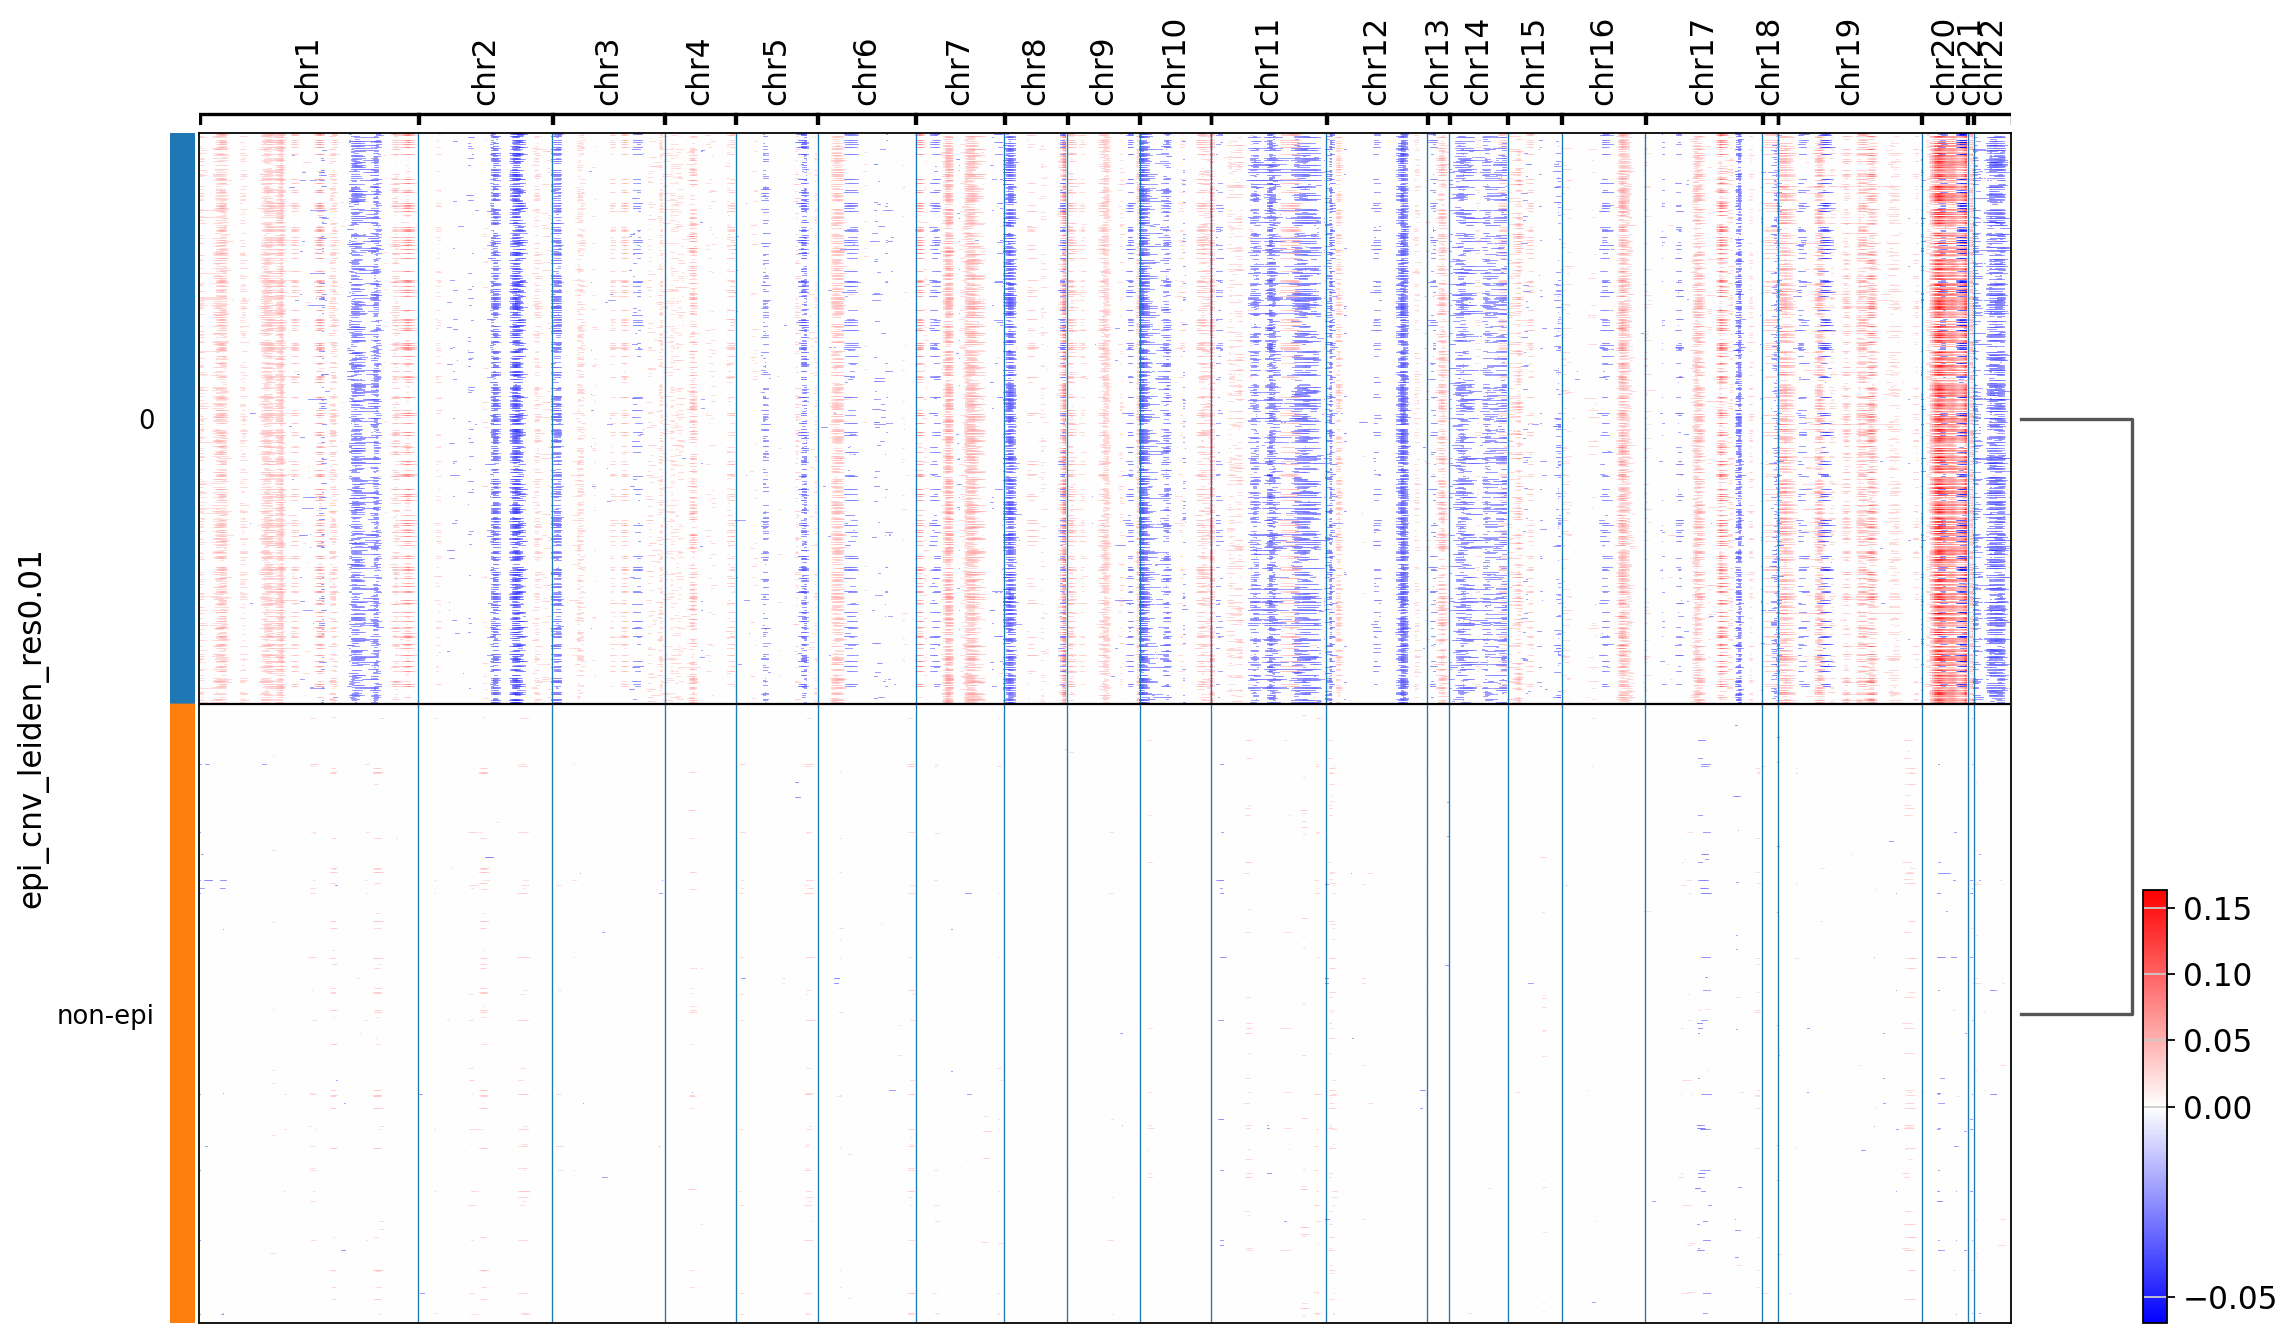

In [12]:
# Select only the epithelial cells and compute dimentionality reduction and nearest neighbor graph based on their CNV profiles
adata_epi = adata[adata.obs.lv1.isin(['epi1', 'epi2', 'epi3', 'epi4'])].copy()
cnv.tl.pca(adata_epi)
cnv.pp.neighbors(adata_epi)

# Testing different resolutions
resolutions=[0.01]
for res in resolutions:    
    #Cluster only the epithelial cells
    key_added=f'epi_cnv_leiden_res{res}'
    cnv.tl.leiden(adata_epi, resolution=res, key_added=key_added)

    # 1. Make sure groupby is categorical and remove unused categories
    adata_epi.obs[key_added] = adata_epi.obs[key_added].astype("category")
    adata_epi.obs[key_added] = adata_epi.obs[key_added].cat.remove_unused_categories()
    
    # 2. Delete stale colors and stale dendrogram
    adata_epi.uns.pop(f"{key_added}_colors", None)
    adata_epi.uns.pop(f"dendrogram_{key_added}", None)

    # Add the epithelial clustering back to the whole snPATHO-seq dataset
    adata.obs[key_added] = 'non-epi'
    adata.obs.loc[adata_epi.obs_names, key_added] = adata_epi.obs[key_added]
    adata.obs[key_added] = adata.obs[key_added].astype("category")

    # Plot the heatmaps
    sc.tl.dendrogram(adata, groupby=key_added)
    # save_heatmap = f"_snPATHOseq_{sid}_common_groupby-{key_added}.pdf"
    save_heatmap =None
    sc.tl.dendrogram(adata, groupby=key_added)
    cnv.pl.chromosome_heatmap(adata, groupby=key_added, dendrogram=True, save=save_heatmap)#, vmin=-.4, vmax=.4

## Save new adata object with CNV information

In [13]:
adata

AnnData object with n_obs × n_vars = 2094 × 14044
    obs: 'pid', 'run', 'sid', 'sum', 'detected', 'subsets_mt_sum', 'subsets_mt_detected', 'subsets_mt_percent', 'total', 'sizeFactor', 'kid', 'decontX_contamination', 'decontX_clusters', 'sum.1', 'detected.1', 'subsets_mt_sum.1', 'subsets_mt_detected.1', 'subsets_mt_percent.1', 'total.1', 'scDblFinder.sample', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'lv1', 'barcode', 'epi_cnv_leiden_res0.01'
    var: 'ensembl_id', 'gene_symbol', 'subsets_mt', 'gene_id', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    uns: 'X_name', 'lv1_colors', 'scDblFinder.stats', 'scDblFinder.threshold', 'sid_colors', 'neighbors', 'log1p', 'cnv', 'dendrogram_epi_cnv_leiden_res0.01', 'epi_cnv_leiden_res0.01_colors'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap', 'X_cnv'
    layers: 'X', 'logcounts', 'raw', '

In [14]:
adata.write("/home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/01_insituCNV/data/snPATHOseq_221_common_CNVinf.h5ad", compression ='gzip')

In [ ]:
adata = sc.read_h5ad("/home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/01_insituCNV/data/snPATHOseq_221_common_CNVinf.h5ad")

## Plot and save heatmap figure

categories: 0, non-epi
var_group_labels: chr1, chr2, chr3, etc.


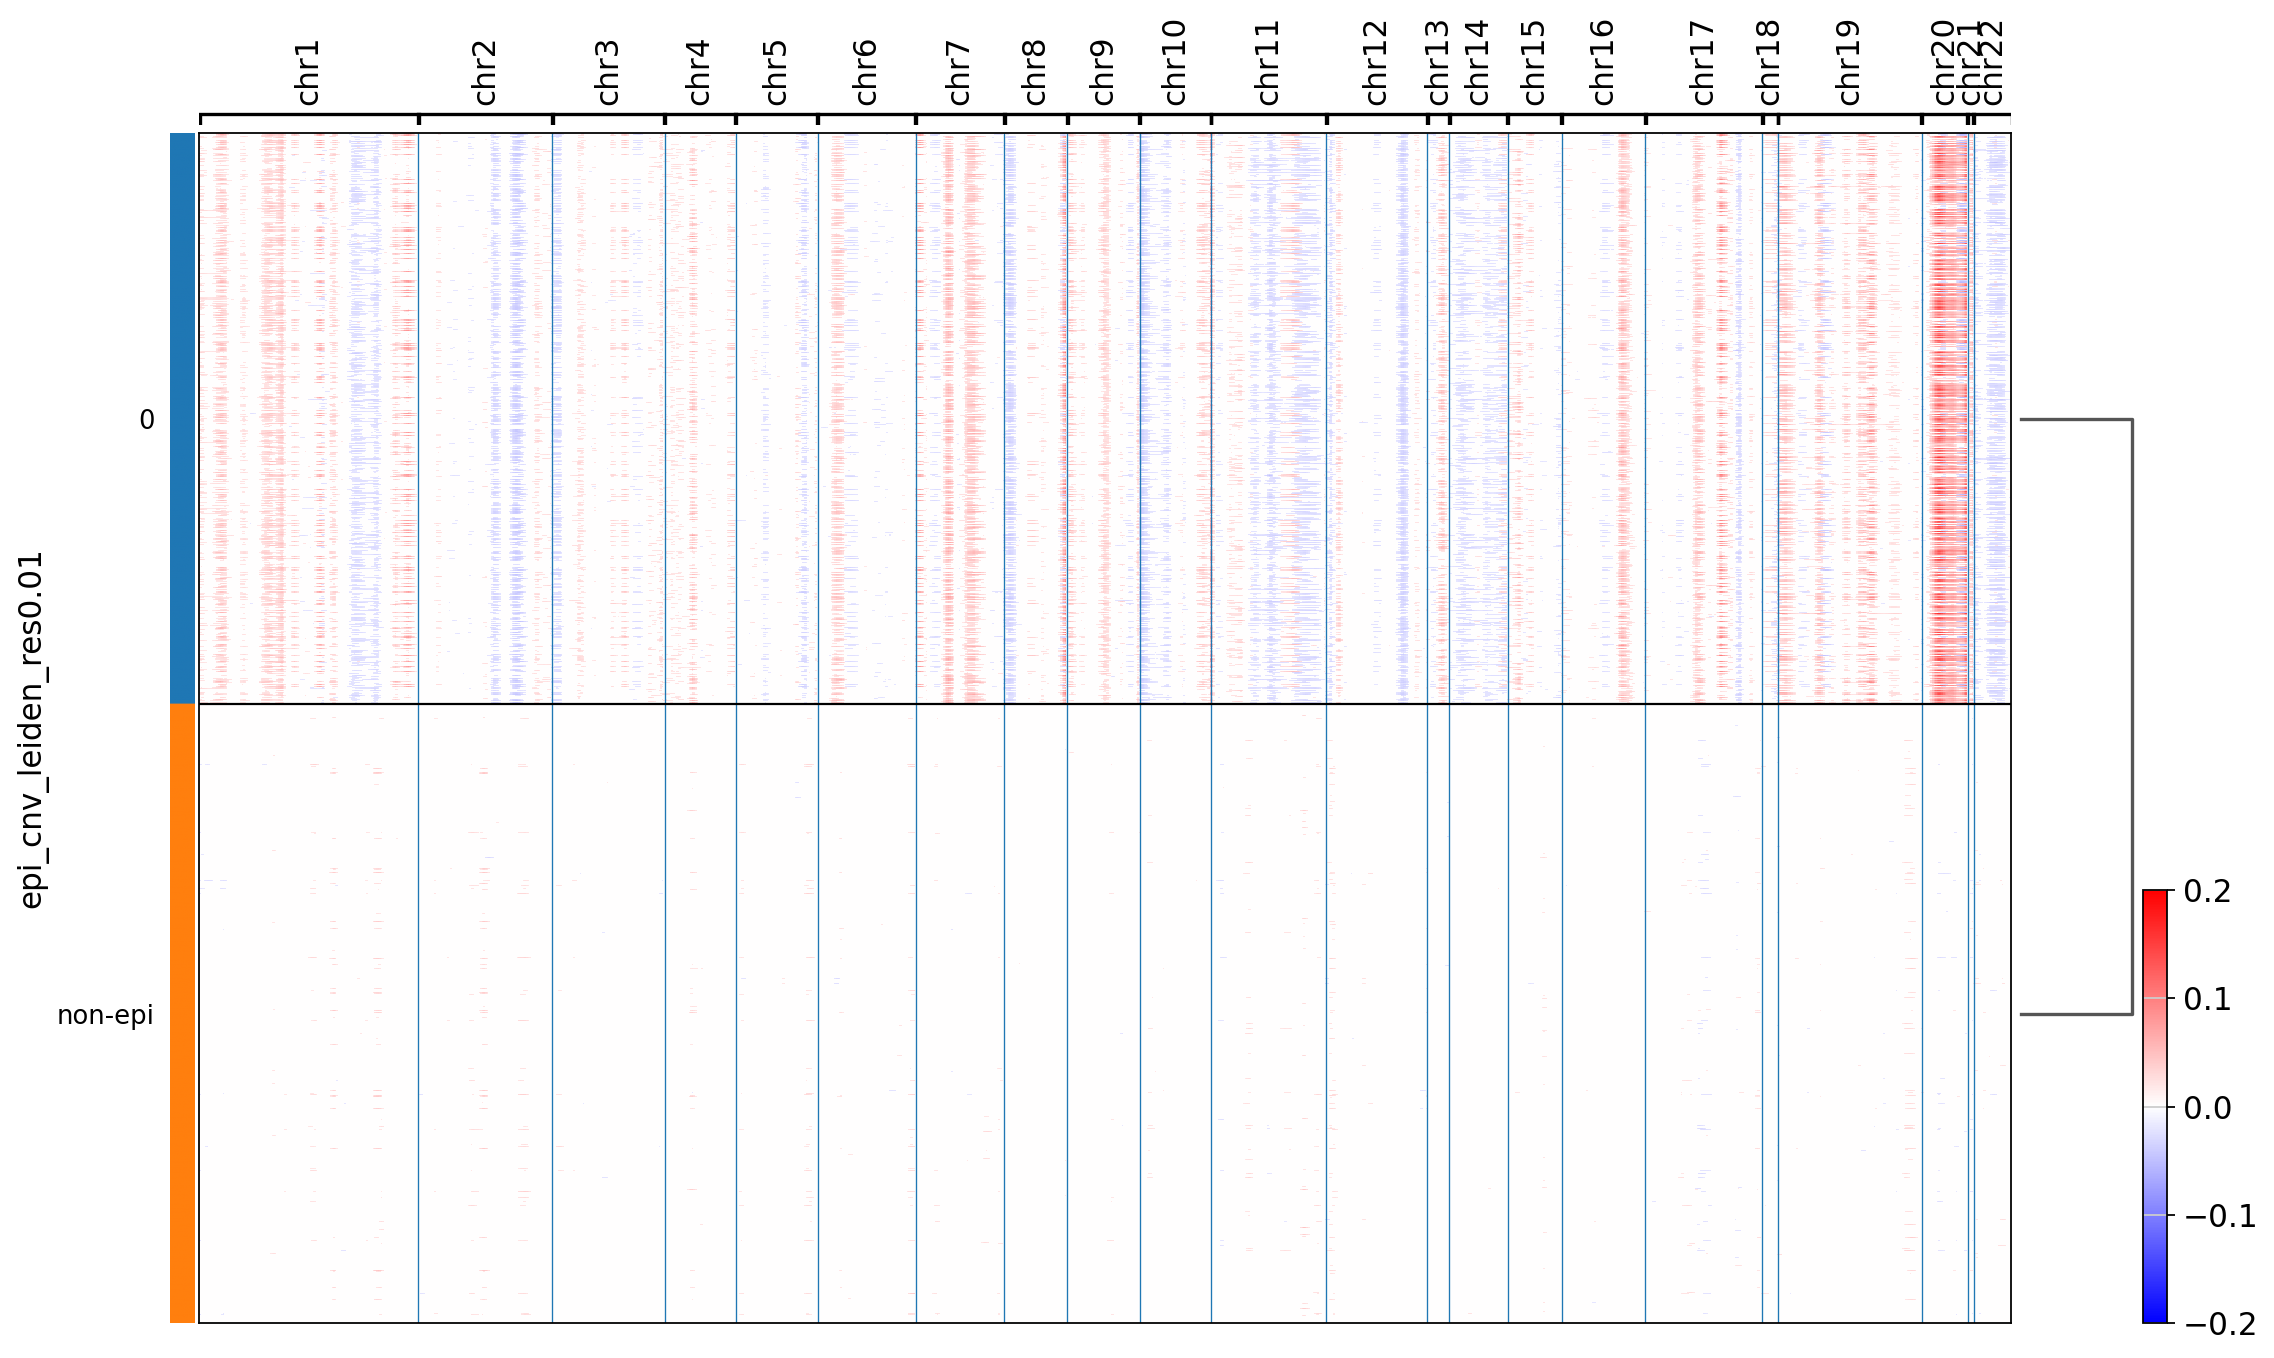

In [16]:
sid ='221'
groupby='epi_cnv_leiden_res0.01'
save_heatmap = f"_summary_snPATHOseq_{sid}_groupby-{groupby}.pdf"
save_heatmap = None
cnv.pl.chromosome_heatmap(adata, groupby=groupby, dendrogram=True, save=save_heatmap, vmin=-.2, vmax=.2)